In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as pl
from ufo_functions import *
from scipy.interpolate import UnivariateSpline as spline

In [37]:
run_settings = settings('halibut_settings.txt')
elements = run_settings.elements
densities = run_settings.densities
lc_name = run_settings.lightcurve
spectra_dir = run_settings.spectra_dir

In [38]:
ebins=np.loadtxt('flux_resolved_spectra/ebins.dat')
spec1=np.loadtxt('flux_resolved_spectra/density_1e-06_flux_5.dat')
spec2=np.loadtxt('flux_resolved_spectra/density_1e-08_flux_5.dat')

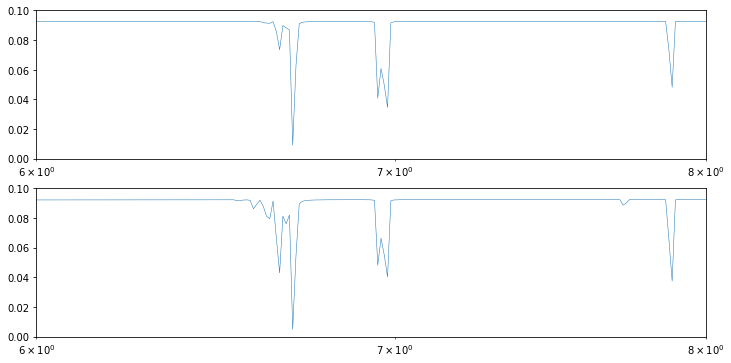

In [39]:
fig=pl.figure(figsize=(12,6))

ymax=0.1
xmin=6
xmax=8

ax1=pl.subplot(211)
ax1.set_xscale('log')
ax1.set_xlim(xmin,xmax)
ax1.set_ylim(0,ymax)
pl.plot(ebins,spec1,lw=0.5)

ax2=pl.subplot(212)
ax2.set_xscale('log')
ax2.set_xlim(xmin,xmax)
ax2.set_ylim(0,ymax)
pl.plot(ebins,spec2,lw=0.5)

pl.show()

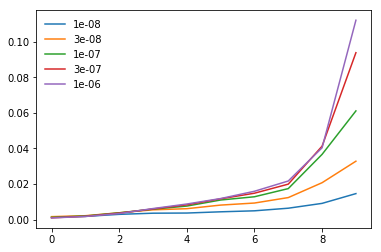

In [47]:

for density in densities:
    ratios=[]
    for interval in range(1,11):
        spectrum=np.loadtxt('flux_resolved_spectra/density_%s_flux_%s.dat' % (str(density),str(interval)))
        temp_spline=spline(ebins,spectrum,s=0)
        ratios.append(temp_spline(6.7)/1.)
#         pl.plot(ebins,spectrum)
#         pl.plot(,temp_spline(ebins))
    pl.plot(ratios,label=density)
pl.legend(loc='upper left',frameon=False)
pl.show()

#         pl.show()
#         pl.plot(interval, temp_spline(6.7)/temp_spline(6.97),marker='o')
